In [1]:
# ============================================================
# QUANTUM NETWORK MULTI-HOP EMULATION
# ============================================================
# This notebook tests multi-hop quantum state transport across
# multiple nodes on the IBM Fez topology.
#
# Uses the network_emulation package for modular functions.
# ============================================================

import sys
import numpy as np
from pathlib import Path

# Add parent directory to path for network_emulation package
sys.path.insert(0, '..')

# Import from network_emulation package
from network_emulation import (
    # Node utilities
    Node, NODE_NAMES, NUM_NODES, INITIAL_STATES, STATE_LABELS,
    CONNECTION_TUPLES, get_node_name, route_name,
    # Config loading
    load_nodes_config, load_routes_config,
    # Circuit building (including new multi-hop function)
    build_swapping_circuit, build_multihop_swapping_circuit,
    # Experiment execution
    initialize_backend, run_single_experiment, run_full_experiment,
    # Visualization & export
    plot_syndrome_matrix, plot_all_states_comparison, plot_state_averages_bar,
    print_matrix_summary, print_full_comparison, save_results_to_json
)

print("Imports complete - using network_emulation package")
print("  - build_multihop_swapping_circuit() now available")

Imports complete - using network_emulation package
  - build_multihop_swapping_circuit() now available


In [2]:
# ============================================================
# EXPERIMENT CONFIGURATION
# ============================================================
# Set USE_REAL_HARDWARE = True to run on actual IBM quantum hardware
# Set USE_REAL_HARDWARE = False to use the FakeFez simulator
# ============================================================

USE_REAL_HARDWARE = False  # Toggle between real hardware and simulator

# Experiment parameters
NUM_SHOTS = 4096           # Number of shots per circuit execution
OPTIMIZATION_LEVEL = 0      # Transpiler optimization (0 = no optimization)

# Configuration file paths
CONFIG_DIR = Path('../configs')
NODES_FILE = CONFIG_DIR / 'config_1_nodes.json'
ROUTES_FILE = CONFIG_DIR / 'config_1_routes.json'
OUTPUT_DIR = Path('../outputs/syndromes')

print("="*60)
print("EXPERIMENT CONFIGURATION")
print("="*60)
print(f"Hardware mode:      {'REAL IBM HARDWARE' if USE_REAL_HARDWARE else 'FakeFez SIMULATOR'}")
print(f"Shots per circuit:  {NUM_SHOTS}")
print(f"Optimization level: {OPTIMIZATION_LEVEL}")
print(f"Initial states:     {[STATE_LABELS[s] for s in INITIAL_STATES]}")
print(f"\nConfig files:")
print(f"  Nodes:  {NODES_FILE} (exists: {NODES_FILE.exists()})")
print(f"  Routes: {ROUTES_FILE} (exists: {ROUTES_FILE.exists()})")

EXPERIMENT CONFIGURATION
Hardware mode:      FakeFez SIMULATOR
Shots per circuit:  4096
Optimization level: 0
Initial states:     ['|0⟩', '|1⟩', '|+⟩', '|−⟩']

Config files:
  Nodes:  ../configs/config_1_nodes.json (exists: True)
  Routes: ../configs/config_1_routes.json (exists: True)


In [3]:
# ============================================================
# LOAD CONFIGURATIONS
# ============================================================

# Load node and route configurations from JSON files
NODES = load_nodes_config(NODES_FILE)
TRANSPORT_ROUTES = load_routes_config(ROUTES_FILE)

print("="*60)
print("LOADED CONFIGURATIONS")
print("="*60)
print(f"\nNodes ({len(NODES)} total):")
for node_id, qubits in NODES.items():
    print(f"  Node {get_node_name(node_id)}: data={qubits['data']}, "
          f"encoding={qubits['encoding']}, ancilla={qubits['ancilla']}")

print(f"\nRoutes ({len(TRANSPORT_ROUTES)} total)")
print(f"Connection pairs: {len(CONNECTION_TUPLES)}")

LOADED CONFIGURATIONS

Nodes (6 total):
  Node A: data=[76], encoding=[61, 81], ancilla=[62, 82]
  Node B: data=[77], encoding=[65, 85], ancilla=[66, 86]
  Node C: data=[78], encoding=[69, 89], ancilla=[70, 90]
  Node D: data=[96], encoding=[83, 103], ancilla=[84, 104]
  Node E: data=[97], encoding=[87, 107], ancilla=[88, 108]
  Node F: data=[98], encoding=[91, 111], ancilla=[92, 112]

Routes (30 total)
Connection pairs: 30


In [4]:
# ============================================================
# INITIALIZE BACKEND
# ============================================================

# Initialize quantum backend (FakeFez simulator or real IBM Fez)
backend, simulator, coupling_map, IS_REAL_HARDWARE = initialize_backend(
    USE_REAL_HARDWARE,
    secrets_path='../secrets/keys.json',
    simulation_method="matrix_product_state"
)

Loaded SIMULATOR backend: fake_fez
  Qubits: 156
  Simulation method: matrix_product_state


# Run Experiments

The cells below execute the transport experiments. 
- **Single Test**: Quick test of one route
- **Full Experiment**: All routes × all initial states

Test circuit: Node A → Node C, initial state |0⟩
  Qubits: 156
  Classical bits: 2
  Gate count: 42
  Depth: 20


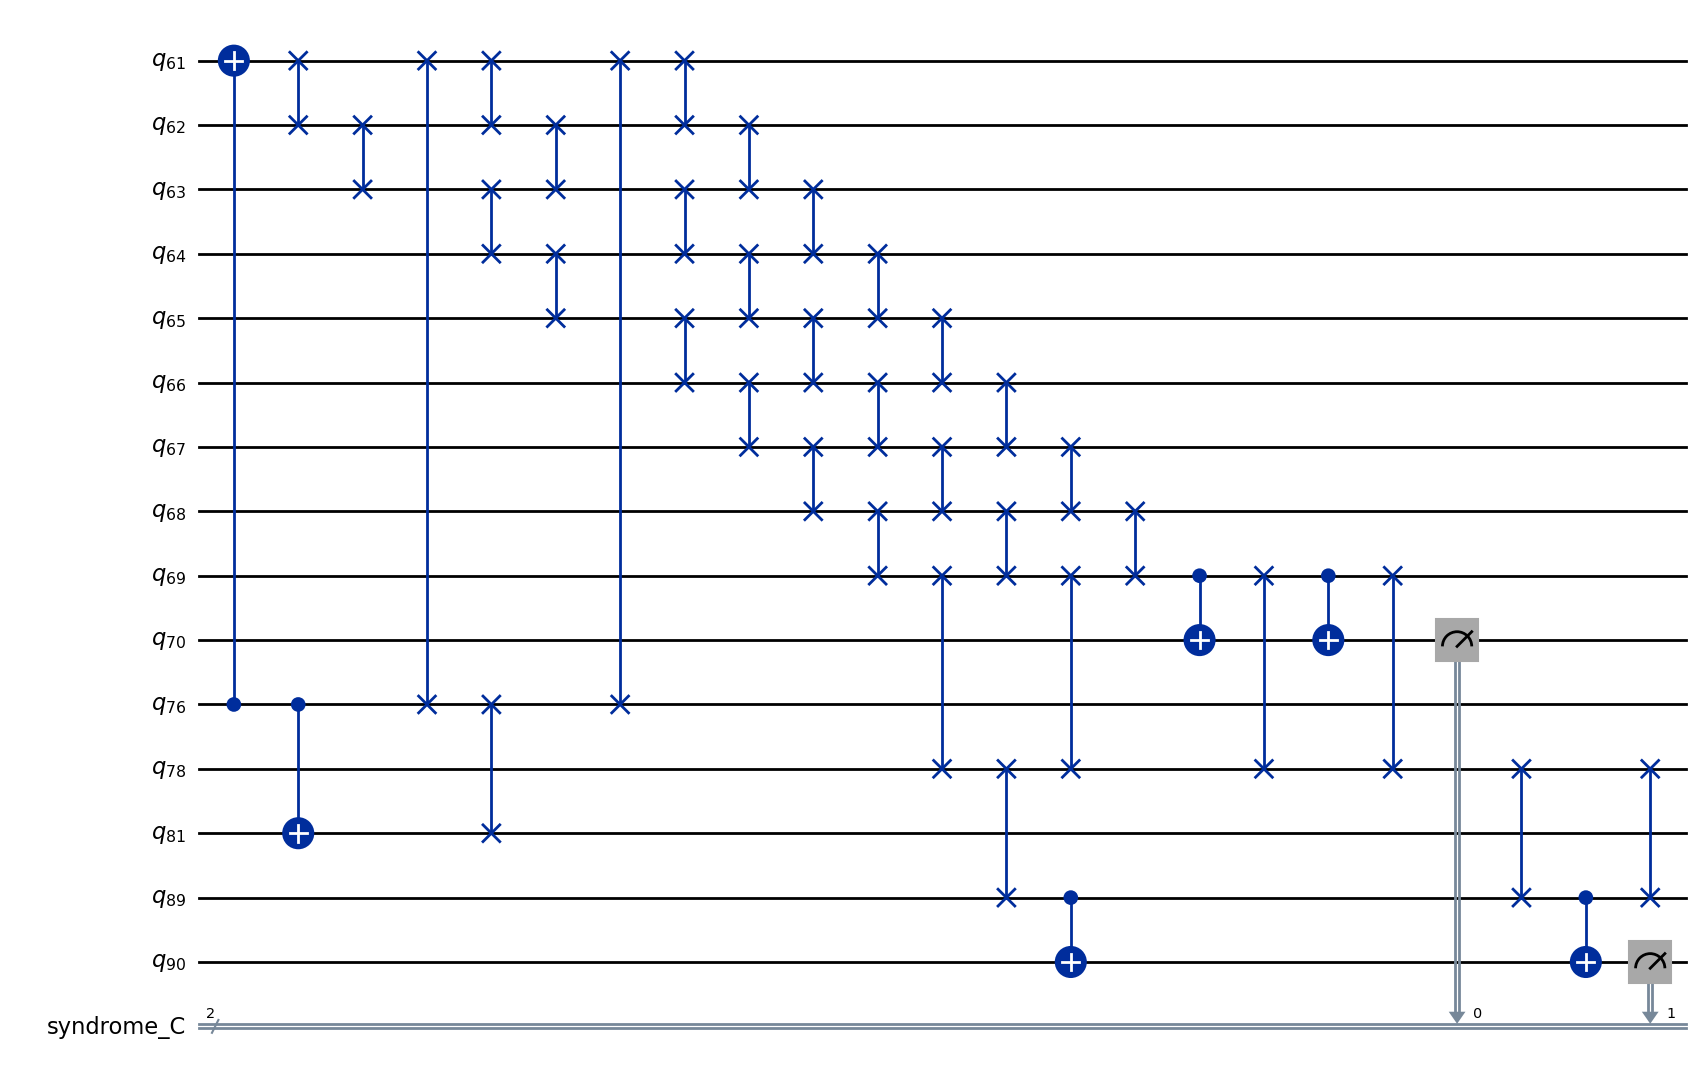

In [5]:
# ============================================================
# QUICK TEST: Single Route
# ============================================================

# Test a single route to verify circuit building
test_circuit = build_swapping_circuit(
    source=Node.A, 
    sink=Node.C, 
    initial_state='0',
    nodes=NODES,
    routes=TRANSPORT_ROUTES,
    num_qubits=backend.num_qubits
)

print(f"Test circuit: Node A → Node C, initial state |0⟩")
print(f"  Qubits: {test_circuit.num_qubits}")
print(f"  Classical bits: {test_circuit.num_clbits}")
print(f"  Gate count: {test_circuit.size()}")
print(f"  Depth: {test_circuit.depth()}")

# Draw the circuit
test_circuit.draw('mpl', fold=-1, idle_wires=False)

# Multi-Hop Circuit Testing

Test the new `build_multihop_swapping_circuit()` function which:
- Takes a path of nodes (e.g., A → B → D → F)
- Optionally measures syndromes at intermediate nodes
- Resets ancillas after mid-circuit measurements

In [6]:
# ============================================================
# TEST 1: Multi-hop circuit with measurement at final node only (default)
# ============================================================
# Path: A → B → D → F (3 hops)

multihop_circuit_1 = build_multihop_swapping_circuit(
    node_path=[Node.A, Node.B, Node.D, Node.F],
    initial_state='+',
    nodes=NODES,
    routes=TRANSPORT_ROUTES,
    num_qubits=backend.num_qubits,
    measure_at=None  # Default: measure only at final node
)

print("Multi-hop circuit: A → B → D → F")
print(f"  Initial state: |+⟩")
print(f"  Measurement: Final node only (F)")
print(f"  Qubits: {multihop_circuit_1.num_qubits}")
print(f"  Classical bits: {multihop_circuit_1.num_clbits}")
print(f"  Gate count: {multihop_circuit_1.size()}")
print(f"  Depth: {multihop_circuit_1.depth()}")

Multi-hop circuit: A → B → D → F
  Initial state: |+⟩
  Measurement: Final node only (F)
  Qubits: 156
  Classical bits: 2
  Gate count: 73
  Depth: 36


In [7]:
# ============================================================
# TEST 2: Multi-hop with intermediate measurements
# ============================================================
# Path: A → B → D → F, measure at B and F

multihop_circuit_2 = build_multihop_swapping_circuit(
    node_path=[Node.A, Node.B, Node.D, Node.F],
    initial_state='+',
    nodes=NODES,
    routes=TRANSPORT_ROUTES,
    num_qubits=backend.num_qubits,
    measure_at=[Node.B, Node.F]  # Measure at intermediate B and final F
)

print("Multi-hop circuit: A → B → D → F")
print(f"  Initial state: |+⟩")
print(f"  Measurement points: B (intermediate), F (final)")
print(f"  Classical bits: {multihop_circuit_2.num_clbits} (2 per measurement point)")
print(f"    c[0:2] = syndromes at Node B")
print(f"    c[2:4] = syndromes at Node F")
print(f"  Gate count: {multihop_circuit_2.size()}")
print(f"  Depth: {multihop_circuit_2.depth()}")

Multi-hop circuit: A → B → D → F
  Initial state: |+⟩
  Measurement points: B (intermediate), F (final)
  Classical bits: 4 (2 per measurement point)
    c[0:2] = syndromes at Node B
    c[2:4] = syndromes at Node F
  Gate count: 85
  Depth: 44


In [8]:
# ============================================================
# TEST 3: Measure at ALL intermediate nodes
# ============================================================
# Path: A → B → D → F, measure at every stop (B, D, F)

multihop_circuit_3 = build_multihop_swapping_circuit(
    node_path=[Node.A, Node.B, Node.D, Node.F],
    initial_state='0',
    nodes=NODES,
    routes=TRANSPORT_ROUTES,
    num_qubits=backend.num_qubits,
    measure_at=[Node.B, Node.D, Node.F]  # Measure at all nodes along the path
)

print("Multi-hop circuit: A → B → D → F")
print(f"  Initial state: |0⟩")
print(f"  Measurement points: B, D, F (all stops)")
print(f"  Classical bits: {multihop_circuit_3.num_clbits}")
print(f"    c[0:2] = syndromes at Node B (with ancilla reset)")
print(f"    c[2:4] = syndromes at Node D (with ancilla reset)")
print(f"    c[4:6] = syndromes at Node F (final, no reset)")
print(f"  Gate count: {multihop_circuit_3.size()}")
print(f"  Depth: {multihop_circuit_3.depth()}")

Multi-hop circuit: A → B → D → F
  Initial state: |0⟩
  Measurement points: B, D, F (all stops)
  Classical bits: 6
    c[0:2] = syndromes at Node B (with ancilla reset)
    c[2:4] = syndromes at Node D (with ancilla reset)
    c[4:6] = syndromes at Node F (final, no reset)
  Gate count: 96
  Depth: 51


In [9]:
# # ============================================================
# # RUN: Execute multi-hop circuit with intermediate measurements
# # ============================================================

from qiskit import transpile

# # Transpile the circuit with intermediate measurements
# transpiled_multihop = transpile(
#     multihop_circuit_2,
#     backend,
#     initial_layout=list(range(backend.num_qubits)),
#     optimization_level=1
# )

# # Run on simulator
# job = simulator.run(transpiled_multihop, shots=NUM_SHOTS)
# multihop_counts = job.result().get_counts()

# print("Multi-hop A → B → D → F results (measured at B and F):")
# print(f"  Total shots: {NUM_SHOTS}")
# print(f"\nSyndrome counts (format: 'FF BB' where FF=Node F, BB=Node B):")
# for outcome, count in sorted(multihop_counts.items(), key=lambda x: -x[1])[:8]:
#     pct = count / NUM_SHOTS * 100
#     print(f"  '{outcome}': {count:4d} ({pct:5.1f}%)")

# # Calculate '0000' rate (no errors at any measurement point)
# no_error_count = multihop_counts.get('0000', multihop_counts.get('00 00', 0))
# print(f"\nAll syndromes '00' rate: {no_error_count/NUM_SHOTS*100:.1f}%")

# Exploring Syndromes through multi-path settings

In [10]:
node_path_1 = [Node.A, Node.D, Node.C, Node.F]
node_path_2 = [Node.A, Node.D, Node.C, Node.F]

multihop_circuit_path_1 = build_multihop_swapping_circuit (
    node_path=node_path_1,
    initial_state='0',
    nodes=NODES,
    routes=TRANSPORT_ROUTES,
    num_qubits=backend.num_qubits,
    measure_at=[Node.D, Node.F],
    syndrome_type='bit'
)

multihop_circuit_path_2 = build_multihop_swapping_circuit (
    node_path=node_path_2,
    initial_state='0',
    nodes=NODES,
    routes=TRANSPORT_ROUTES,
    num_qubits=backend.num_qubits,
    measure_at=[Node.D, Node.F],
    syndrome_type='phase'
)


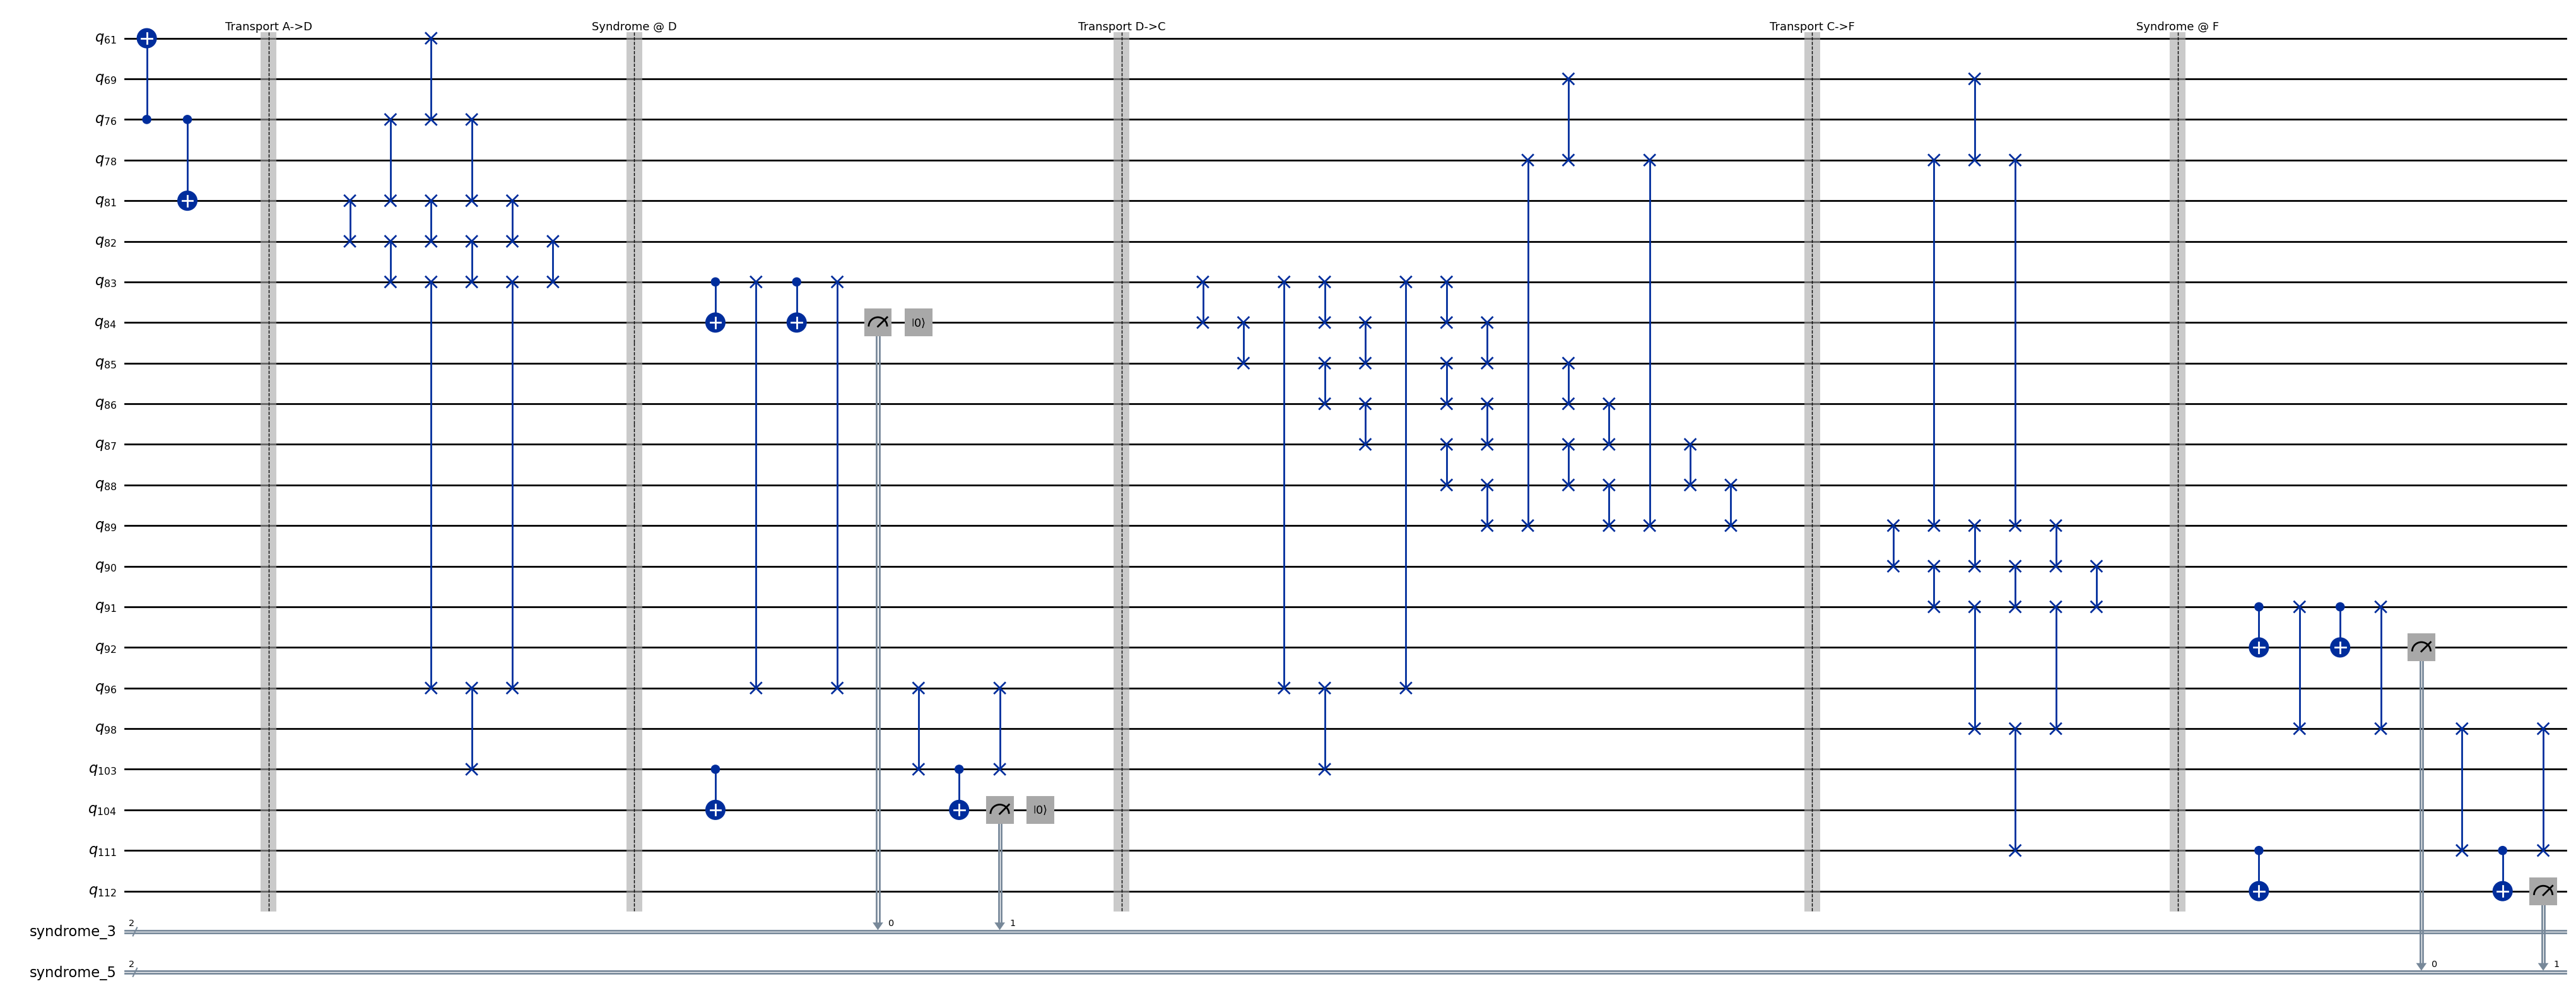

In [11]:
multihop_circuit_path_1.draw('mpl', fold=-1, idle_wires=False)

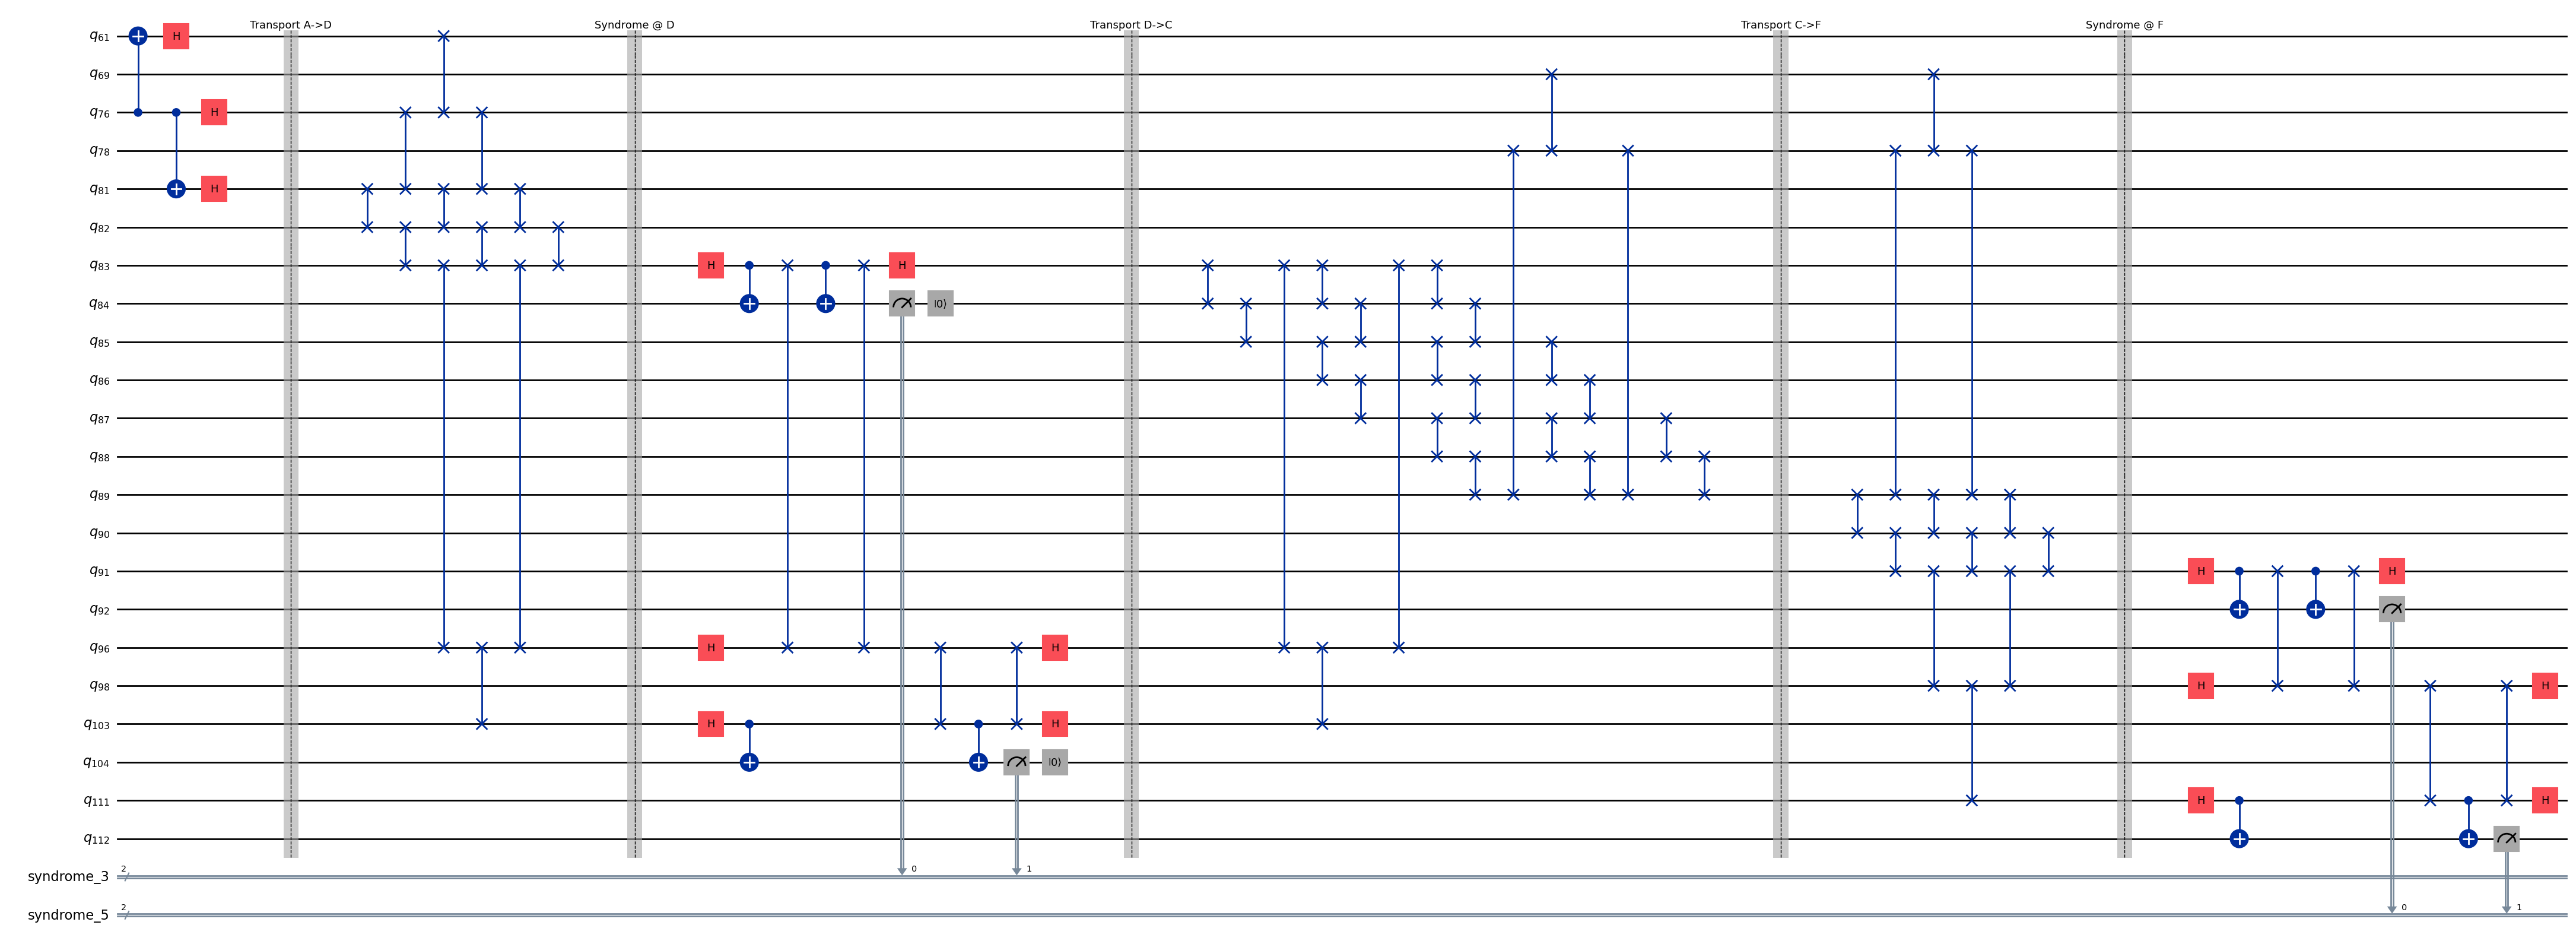

In [12]:
multihop_circuit_path_2.draw('mpl', fold=-1, idle_wires=False)

In [13]:
transpiled_multihop_path_1 = transpile(
    multihop_circuit_path_1,
    backend,
    initial_layout=list(range(backend.num_qubits)),
    optimization_level=1
)

transpiled_multihop_path_2 = transpile(
    multihop_circuit_path_2,
    backend,
    initial_layout=list(range(backend.num_qubits)),
    optimization_level=1
)


In [14]:
# Run path 1 experiment
if IS_REAL_HARDWARE:
    from qiskit_ibm_runtime import SamplerV2
    sampler = SamplerV2(backend)
    job = sampler.run([transpiled_multihop_path_1], shots=NUM_SHOTS)
    print(f"Job submitted to {backend.name}: {job.job_id()}")
    result = job.result()
    # Use join_data() to combine all ClassicalRegisters into one bitstring
    multihop_counts = result[0].join_data().get_counts()
else:
    job = simulator.run(transpiled_multihop_path_1, shots=NUM_SHOTS)
    multihop_counts = job.result().get_counts()

In [15]:

print(f"\nMulti-hop {node_path_1} results (measured at D and F):")
print(f"  Total shots: {NUM_SHOTS}")
print(f"\nBit Syndrome counts (format: 'DD FF' where DD=Node D, FF=Node F):")
for outcome, count in sorted(multihop_counts.items(), key=lambda x: x[0]):
    pct = count / NUM_SHOTS * 100
    print(f"  '{outcome}': {count:4d} ({pct:5.1f}%)")

# Calculate '0000' rate (no errors at any measurement point)
no_error_count = multihop_counts.get('0000', multihop_counts.get('00 00', 0))
print(f"\nAll syndromes '00' rate: {no_error_count/NUM_SHOTS*100:.1f}%")


Multi-hop [<Node.A: 0>, <Node.D: 3>, <Node.C: 2>, <Node.F: 5>] results (measured at D and F):
  Total shots: 4096

Bit Syndrome counts (format: 'DD FF' where DD=Node D, FF=Node F):
  '00 00': 2419 ( 59.1%)
  '00 01':   25 (  0.6%)
  '00 10':   56 (  1.4%)
  '00 11':   27 (  0.7%)
  '01 00':  315 (  7.7%)
  '01 01':  137 (  3.3%)
  '01 10':   31 (  0.8%)
  '01 11':   21 (  0.5%)
  '10 00':  389 (  9.5%)
  '10 01':   22 (  0.5%)
  '10 10':  167 (  4.1%)
  '10 11':   25 (  0.6%)
  '11 00':  260 (  6.3%)
  '11 01':   27 (  0.7%)
  '11 10':   45 (  1.1%)
  '11 11':  130 (  3.2%)

All syndromes '00' rate: 59.1%


In [16]:
# Run path 2 experiment
if IS_REAL_HARDWARE:
    from qiskit_ibm_runtime import SamplerV2
    sampler = SamplerV2(backend)
    job = sampler.run([transpiled_multihop_path_2], shots=NUM_SHOTS)
    print(f"Job submitted to {backend.name}: {job.job_id()}")
    result = job.result()
    # Use join_data() to combine all ClassicalRegisters into one bitstring
    multihop_counts = result[0].join_data().get_counts()
else:
    job = simulator.run(transpiled_multihop_path_2, shots=NUM_SHOTS)
    multihop_counts = job.result().get_counts()

In [17]:

print(f"\nMulti-hop {node_path_2} results (measured at D and F):")
print(f"  Total shots: {NUM_SHOTS}")
print(f"\nPhase Syndrome counts (format: 'DD FF' where DD=Node D, FF=Node F):")
for outcome, count in sorted(multihop_counts.items(), key=lambda x: x[0]):
    pct = count / NUM_SHOTS * 100
    print(f"  '{outcome}': {count:4d} ({pct:5.1f}%)")

# Calculate '0000' rate (no errors at any measurement point)
no_error_count = multihop_counts.get('0000', multihop_counts.get('00 00', 0))
print(f"\nAll syndromes '00' rate: {no_error_count/NUM_SHOTS*100:.1f}%")


Multi-hop [<Node.A: 0>, <Node.D: 3>, <Node.C: 2>, <Node.F: 5>] results (measured at D and F):
  Total shots: 4096

Phase Syndrome counts (format: 'DD FF' where DD=Node D, FF=Node F):
  '00 00': 2269 ( 55.4%)
  '00 01':   49 (  1.2%)
  '00 10':   63 (  1.5%)
  '00 11':   18 (  0.4%)
  '01 00':  336 (  8.2%)
  '01 01':  159 (  3.9%)
  '01 10':   36 (  0.9%)
  '01 11':   25 (  0.6%)
  '10 00':  358 (  8.7%)
  '10 01':   25 (  0.6%)
  '10 10':  171 (  4.2%)
  '10 11':   26 (  0.6%)
  '11 00':  320 (  7.8%)
  '11 01':   41 (  1.0%)
  '11 10':   65 (  1.6%)
  '11 11':  135 (  3.3%)

All syndromes '00' rate: 55.4%
